# EDA — Corpus HAHA 2019
Análisis exploratorio antes de tocar el modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from transformers import AutoTokenizer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/raw/haha_2019_train.csv')
print(df.shape)
df.head()

/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(24000, 10)


,id,text,is_humor,votes_no,votes_1,votes_2,votes_3,votes_4,votes_5,funniness_average
0,705196579758583809,Niveles de retraso mental: \r\n\r\n— Bajo.\r\n...,1,1,2,2,0,0,0,1.5
1,678040651817213952,"—Vamos Luke desenfunda tu sable, demuestra tu ...",1,1,3,0,1,0,0,1.5
2,546750892213829633,"- ¿Te ofrezco algo?, ¿Agua, café, mi corazón, ...",1,0,2,1,0,1,1,2.6
3,965807211292364801,No se porqué me hago la cabeza deooos,0,3,0,0,0,0,0,NaN
4,638403841839484928,Quisiera saber que hago durante la siesta de l...,0,4,0,1,0,0,0,NaN


## 1. Vista general

In [4]:
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print(f'\nDuplicados en text: {df.duplicated(subset=["text"]).sum()}')

id                     int64
text                     str
is_humor               int64
votes_no               int64
votes_1                int64
votes_2                int64
votes_3                int64
votes_4                int64
votes_5                int64
funniness_average    float64
dtype: object

Nulos:
id                       0
text                     0
is_humor                 0
votes_no                 0
votes_1                  0
votes_2                  0
votes_3                  0
votes_4                  0
votes_5                  0
funniness_average    14747
dtype: int64

Duplicados en text: 0


## 2. Balance de clases

is_humor
0    14747
1     9253
Name: count, dtype: int64

Ratio humor/no-humor: 0.63


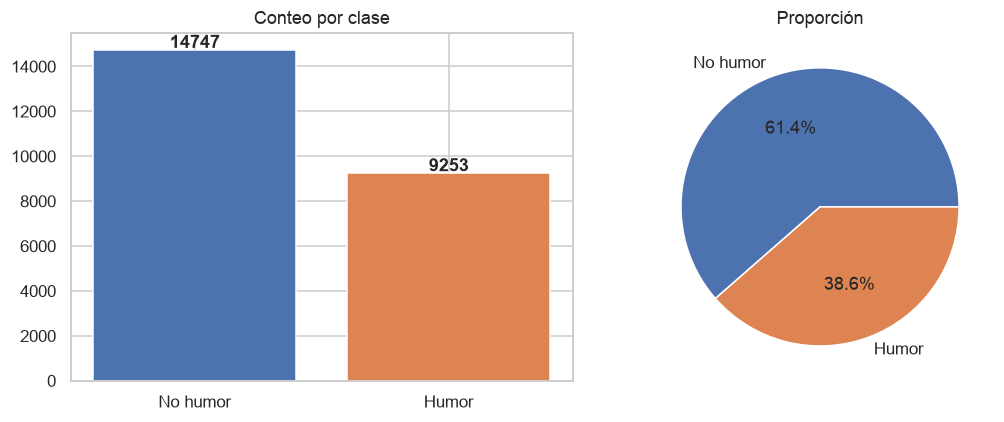

In [5]:
counts = df['is_humor'].value_counts()
print(counts)
print(f'\nRatio humor/no-humor: {counts[1]/counts[0]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['No humor', 'Humor'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Conteo por clase')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No humor', 'Humor'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
axes[1].set_title('Proporción')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

## 3. Longitud de los tweets

            count  mean  std  min   25%   50%   75%   max
is_humor                                                 
0         14747.0  12.4  6.5  1.0   7.0  11.0  17.0  38.0
1          9253.0  17.9  5.9  1.0  13.0  18.0  23.0  47.0


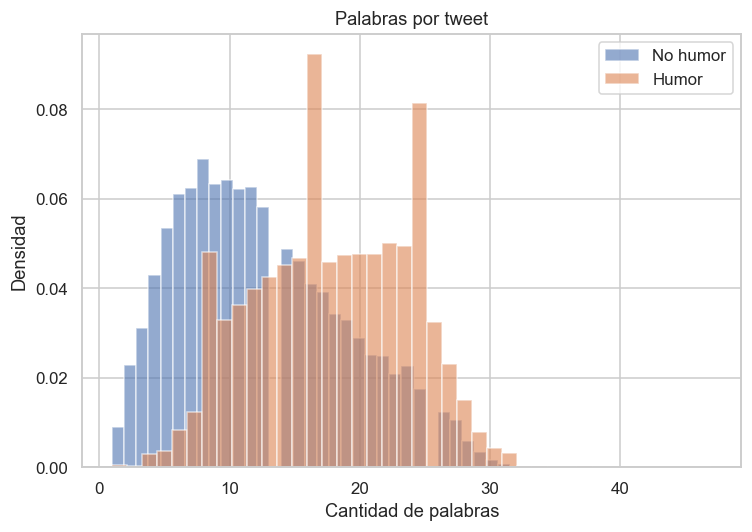

In [2]:
df['n_words'] = df['text'].str.split().str.len()

print(df.groupby('is_humor')['n_words'].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 5))
for label, grp in df.groupby('is_humor'):
    name = 'Humor' if label == 1 else 'No humor'
    ax.hist(grp['n_words'], bins=40, alpha=0.6, label=name, density=True)

ax.set_title('Palabras por tweet')
ax.set_xlabel('Cantidad de palabras')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tokens reales vs. límite max_length=128
Esto importa para decidir si 128 tokens es suficiente o hay mucho truncamiento.

In [ ]:
from transformers import AutoTokenizer

Tweets con >128 tokens: 0/2000 (0.0%)


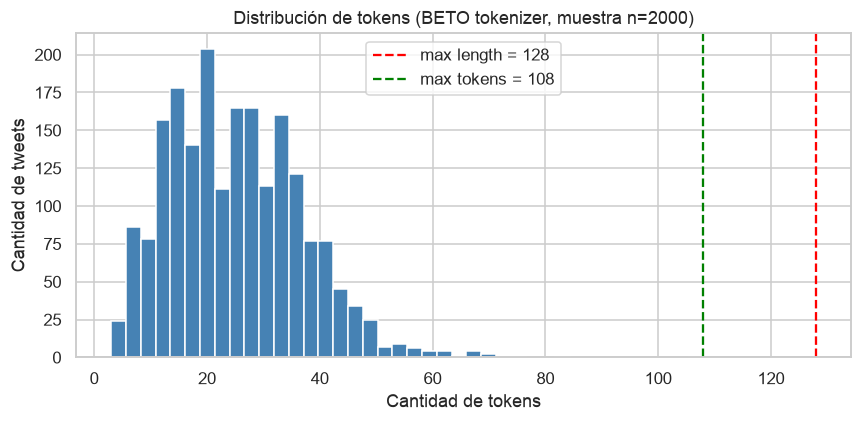

In [12]:

tokenizer = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')

sample = df.sample(2000, random_state=42)
sample = sample.copy()
sample['n_tokens'] = sample['text'].apply(
    lambda t: len(tokenizer.encode(t, add_special_tokens=True))
)

truncated = (sample['n_tokens'] > 128).sum()
print(f'Tweets con >128 tokens: {truncated}/{len(sample)} ({100*truncated/len(sample):.1f}%)')

plt.figure(figsize=(8, 4))
plt.hist(sample['n_tokens'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='max length = 128')
plt.axvline(max(sample['n_tokens']), color='green', linestyle='--', label=f'max tokens = {max(sample["n_tokens"])}')
plt.title('Distribución de tokens (BETO tokenizer, muestra n=2000)')
plt.xlabel('Cantidad de tokens')
plt.ylabel('Cantidad de tweets')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/token_distribution.png', dpi=150)
plt.show()

In [ ]:
sample = df.sample(2000, random_state=42)
sample = sample.copy()
sample['n_tokens'] = sample['text'].apply(
    lambda t: len(tokenizer.encode(t, add_special_tokens=True))
)

truncated = (sample['n_tokens'] > 128).sum()
print(f'Tweets con >128 tokens: {truncated}/{len(sample)} ({100*truncated/len(sample):.1f}%)')

plt.figure(figsize=(8, 4))
plt.hist(sample['n_tokens'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='max length = 128')
plt.axvline(max(sample['n_tokens']), color = 'green', linestyle='--', label= f'max tokens = {max(sample['n_tokens'])}')
plt.title('Distribución de tokens (BETO tokenizer, muestra n=2000)')
plt.xlabel('Tokens')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/token_distribution.png', dpi=150)
plt.show()

NameError: name 'tokenizer' is not defined

## 5. Palabras más frecuentes por clase

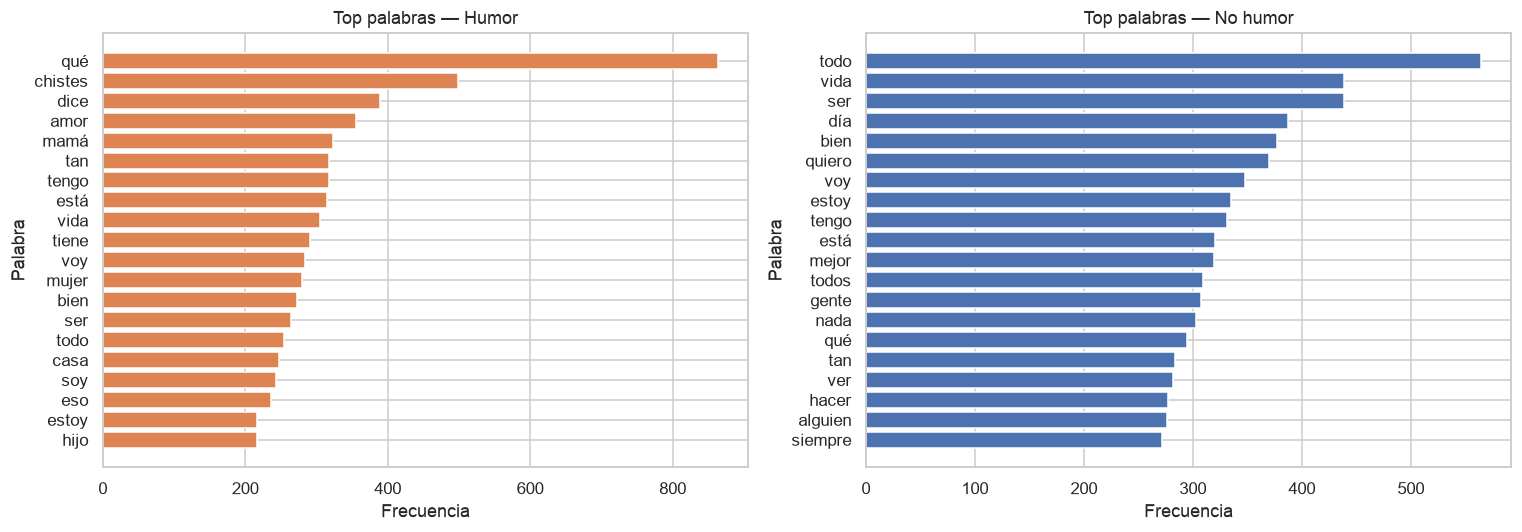

In [8]:
STOPWORDS = {'de','la','el','en','y','a','que','los','se','del','las','un','por',
             'con','una','su','para','es','al','lo','como','más','pero','sus','le',
             'ya','o','fue','este','ha','si','me','porque','esta','son','entre',
             'cuando','muy','sin','sobre','también','mi','hay','te','no','lo','le'}

def top_words(texts, n=20):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'\b[a-záéíóúüñ]{3,}\b', t)
                  if w.lower() not in STOPWORDS]
    return Counter(words).most_common(n)

hw = top_words(df[df['is_humor']==1]['text'])
nw = top_words(df[df['is_humor']==0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, words, title, color in [
    (axes[0], hw, 'Top palabras — Humor',    '#DD8452'),
    (axes[1], nw, 'Top palabras — No humor', '#4C72B0'),
]:
    w, c = zip(*words)
    ax.barh(list(reversed(w)), list(reversed(c)), color=color)
    ax.set_title(title)
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('Palabra')

plt.tight_layout()
plt.savefig('../results/figures/top_words.png', dpi=150)
plt.show()

## 6. Humor rating (si está disponible)

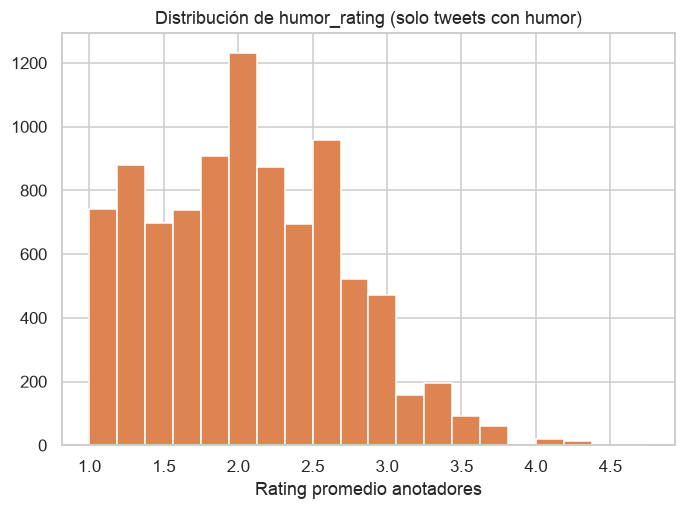

In [11]:
if 'funniness_average' in df.columns:
    df[df['is_humor']==1]['funniness_average'].hist(bins=20, color='#DD8452', edgecolor='white')
    plt.title('Distribución de humor_rating (solo tweets con humor)')
    plt.xlabel('Rating promedio anotadores')
    plt.tight_layout()
    plt.savefig('../results/figures/humor_rating.png', dpi=150)
    plt.show()
else:
    print('No hay columna humor_rating en este dataset.')

## 7. Ejemplos representativos

In [34]:
print('=== MUY GRACIOSO ===')
gracioso = df[(df['is_humor']==1) & (df['funniness_average'] > 3)].sample(1)
print(gracioso['text'].values[0])
print(f"funniness_average: {gracioso['funniness_average'].values[0]:.2f}")

print('\n=== NO GRACIOSO ===')
no_gracioso = df[df['is_humor']==0].sample(1)
print(no_gracioso['text'].values[0])

print('\n=== AMBIGUO ===')
ambiguo = df[(df['ratio'] > 0.4) & (df['ratio'] < 0.6)].sample(1)
print(ambiguo['text'].values[0])
print(f"votos humor: {ambiguo['votos_humor'].values[0]} | votos no humor: {ambiguo['votes_no'].values[0]}")

=== MUY GRACIOSO ===
 Voy Amarte.  ¿Lo prometes?  Si, soy astronauta.
funniness_average: 3.67

=== NO GRACIOSO ===
@los40colombia Hola, podría sonar el temazo #ComoYoTeQuiero de Maite Perroni ft. Alexis y Fido en tu programacíon? Gracias!

=== AMBIGUO ===
Mi uber driver venía jugando pokemon go, 5 estrellitas.
votos humor: 4 | votos no humor: 3


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/var/folders/xh/vtdgtfbx2p93trfvxphlzhgh0000gn/T/ipykernel_6600/1350029308.py:3: SyntaxWarning: invalid escape sequence '\.'
  df['tiene_puntos_suspensivos'] = df['text'].str.contains('\.\.\.').astype(int)


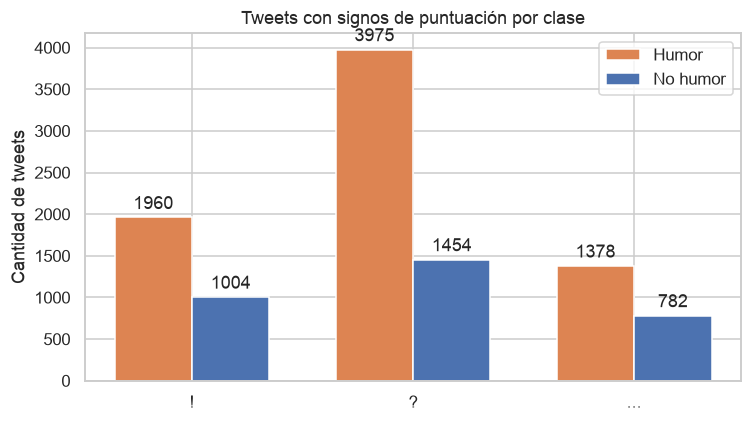

In [38]:
df['tiene_exclamacion'] = df['text'].str.contains('!').astype(int)
df['tiene_pregunta'] = df['text'].str.contains('?', regex=False).astype(int)
df['tiene_puntos_suspensivos'] = df['text'].str.contains('\.\.\.').astype(int)

signos = ['!', '?', '...']
cols   = ['tiene_exclamacion', 'tiene_pregunta', 'tiene_puntos_suspensivos']

humor_counts    = [df[df['is_humor']==1][col].sum() for col in cols]
no_humor_counts = [df[df['is_humor']==0][col].sum() for col in cols]

x = np.arange(len(signos))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, humor_counts,    width, label='Humor',    color='#DD8452')
bars2 = ax.bar(x + width/2, no_humor_counts, width, label='No humor', color='#4C72B0')

ax.set_xticks(x)
ax.set_xticklabels(signos)
ax.set_title('Tweets con signos de puntuación por clase')
ax.set_ylabel('Cantidad de tweets')
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
plt.tight_layout()
plt.savefig('../results/figures/puntuacion.png', dpi=150)
plt.show()